**Set environment**

In [1]:
import numpy  as np
import pandas as pd
import pickle
import os

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



## Import data

**Check file existent**

In [3]:
%%bash -s "{FD_RES}"
echo $1

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results


In [4]:
!ls $FD_RES/analysis_variant_motif_richard/motifdelta_top_jaspar2024

variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top01k.delta.event.tsv
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top01k.delta.results.npz
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top01k.delta.summary_motif.tsv
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top01k.delta.summary_variant.tsv
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top10k.delta.event.tsv
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top10k.delta.results.npz
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top10k.delta.summary_motif.tsv
variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top10k.delta.summary_variant.tsv


**Import table**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

fp_npz = os.path.join(
    FD_RES,
    "analysis_variant_motif_richard",
    "motifdelta_top_jaspar2024",
    "variant_closed_gof_bluestarr.flankL35R70.unobs_vs_obs.top01k.delta.results.npz"
)

obj = np.load(fp_npz, allow_pickle=True)

print(obj.files)

['Tbind', 'Gain_Any', 'Loss_Any', 'Gain_Delta', 'Loss_Delta', 'Gain_Index', 'Loss_Index', 'Gain_Obs', 'Gain_Ubs', 'Loss_Obs', 'Loss_Ubs', 'Idx_Sequence', 'Idx_Motif', 'P']


In [6]:
motif_name = "MA1145.2 FOSL2::JUND"

idx_motif = list(obj["Idx_Motif"]).index(motif_name)
P = int(obj["P"][0])   # number of positions per strand

print("Motif index:", idx_motif)
print("Window length P:", P)

Motif index: 557
Window length P: 74


In [7]:
def decode_index(arr_idx):
    """Return (pos, strand) arrays, excluding invalid entries (-1)."""
    mask = arr_idx >= 0
    idx  = arr_idx[mask]
    pos  = idx // 2
    strand = idx % 2
    return pos, strand

In [8]:
# Gain
gain_any   = obj["Gain_Any"][:, idx_motif]
gain_idx   = obj["Gain_Index"][:, idx_motif]

gain_pos, gain_strand = decode_index(gain_idx[gain_any])

# Loss
loss_any   = obj["Loss_Any"][:, idx_motif]
loss_idx   = obj["Loss_Index"][:, idx_motif]

loss_pos, loss_strand = decode_index(loss_idx[loss_any])

print("Gain events:", len(gain_pos))
print("Loss events:", len(loss_pos))

Gain events: 430
Loss events: 18


In [9]:
bins = np.arange(P + 1)

gain_fwd = np.histogram(gain_pos[gain_strand == 0], bins=bins)[0]
gain_rev = np.histogram(gain_pos[gain_strand == 1], bins=bins)[0]

loss_fwd = np.histogram(loss_pos[loss_strand == 0], bins=bins)[0]
loss_rev = np.histogram(loss_pos[loss_strand == 1], bins=bins)[0]

## Plot: positional footprint (publication-grade)

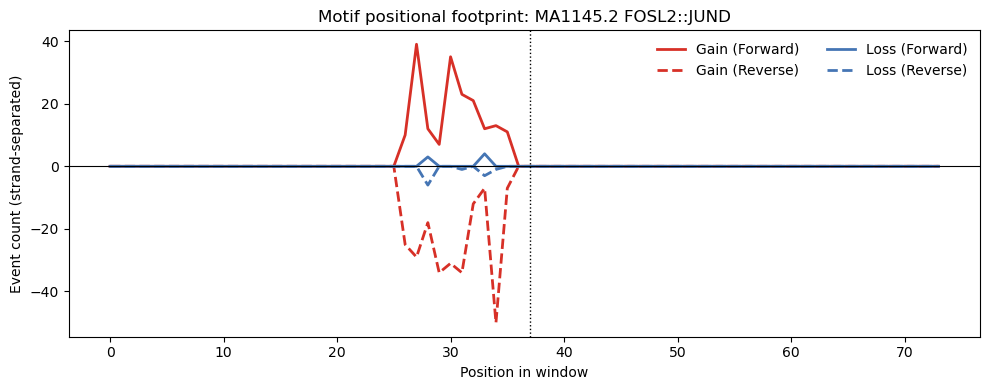

In [10]:
x = np.arange(P)

plt.figure(figsize=(10, 4))

# Gain
plt.plot(x, gain_fwd, color="#d73027", lw=2, label="Gain (Forward)")
plt.plot(x, -gain_rev, color="#d73027", lw=2, ls="--", label="Gain (Reverse)")

# Loss
plt.plot(x, loss_fwd, color="#4575b4", lw=2, label="Loss (Forward)")
plt.plot(x, -loss_rev, color="#4575b4", lw=2, ls="--", label="Loss (Reverse)")

# Center line
plt.axvline(P // 2, color="black", lw=1, ls=":")

plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Position in window")
plt.ylabel("Event count (strand-separated)")
plt.title(f"Motif positional footprint: {motif_name}")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

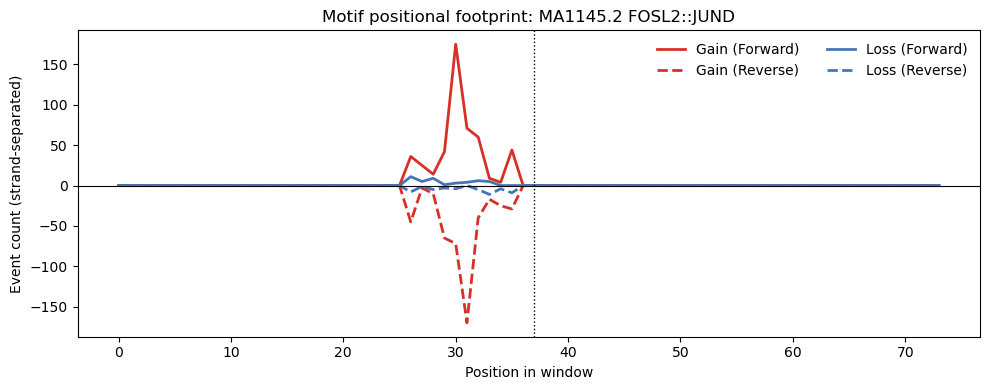

In [14]:
x = np.arange(P)

plt.figure(figsize=(10, 4))

# Gain
plt.plot(x, gain_fwd, color="#d73027", lw=2, label="Gain (Forward)")
plt.plot(x, -gain_rev, color="#d73027", lw=2, ls="--", label="Gain (Reverse)")

# Loss
plt.plot(x, loss_fwd, color="#4575b4", lw=2, label="Loss (Forward)")
plt.plot(x, -loss_rev, color="#4575b4", lw=2, ls="--", label="Loss (Reverse)")

# Center line
plt.axvline(P // 2, color="black", lw=1, ls=":")

plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Position in window")
plt.ylabel("Event count (strand-separated)")
plt.title(f"Motif positional footprint: {motif_name}")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [16]:
N = obj["Idx_Sequence"].shape[0]  # total variants (10k)
gain_fwd_norm = gain_fwd / N
gain_rev_norm = gain_rev / N
loss_fwd_norm = loss_fwd / N
loss_rev_norm = loss_rev / N

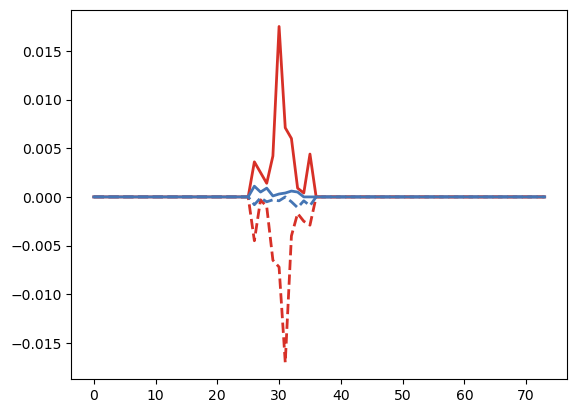

In [17]:
plt.plot(x, gain_fwd_norm, color="#d73027", lw=2, label="Gain (Forward)")
plt.plot(x, -gain_rev_norm, color="#d73027", lw=2, ls="--", label="Gain (Reverse)")

plt.plot(x, loss_fwd_norm, color="#4575b4", lw=2, label="Loss (Forward)")
plt.plot(x, -loss_rev_norm, color="#4575b4", lw=2, ls="--", label="Loss (Reverse)")

In [18]:
import numpy as np

def get_motif_index(obj, motif_name: str) -> int:
    motifs = list(obj["Idx_Motif"])
    if motif_name not in motifs:
        raise KeyError(f"Motif not found: {motif_name}")
    return motifs.index(motif_name)

def decode_flat_index(idx_flat: np.ndarray):
    """
    idx_flat: array of flattened indices into (P*2), where idx = pos*2 + strand
    Returns pos, strand (0=Fwd, 1=Rev) for idx>=0.
    """
    mask = idx_flat >= 0
    idx = idx_flat[mask]
    pos = idx // 2
    strand = idx % 2
    return pos, strand, mask

## Strand-aware positional footprint (counts)

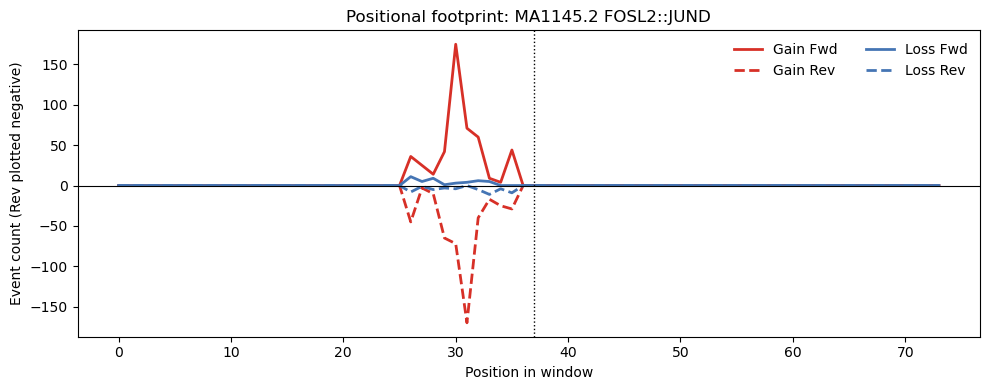

In [19]:
motif_name = "MA1145.2 FOSL2::JUND"
m = get_motif_index(obj, motif_name)
P = int(obj["P"][0])

gain_any = obj["Gain_Any"][:, m]
loss_any = obj["Loss_Any"][:, m]

gain_idx = obj["Gain_Index"][:, m]
loss_idx = obj["Loss_Index"][:, m]

gain_pos, gain_strand, _ = decode_flat_index(gain_idx[gain_any])
loss_pos, loss_strand, _ = decode_flat_index(loss_idx[loss_any])

bins = np.arange(P + 1)
gain_fwd = np.histogram(gain_pos[gain_strand == 0], bins=bins)[0]
gain_rev = np.histogram(gain_pos[gain_strand == 1], bins=bins)[0]
loss_fwd = np.histogram(loss_pos[loss_strand == 0], bins=bins)[0]
loss_rev = np.histogram(loss_pos[loss_strand == 1], bins=bins)[0]

x = np.arange(P)
plt.figure(figsize=(10, 4))
plt.plot(x, gain_fwd, color="#d73027", lw=2, label="Gain Fwd")
plt.plot(x, -gain_rev, color="#d73027", lw=2, ls="--", label="Gain Rev")
plt.plot(x, loss_fwd, color="#4575b4", lw=2, label="Loss Fwd")
plt.plot(x, -loss_rev, color="#4575b4", lw=2, ls="--", label="Loss Rev")
plt.axvline(P // 2, color="black", lw=1, ls=":")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Position in window")
plt.ylabel("Event count (Rev plotted negative)")
plt.title(f"Positional footprint: {motif_name}")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

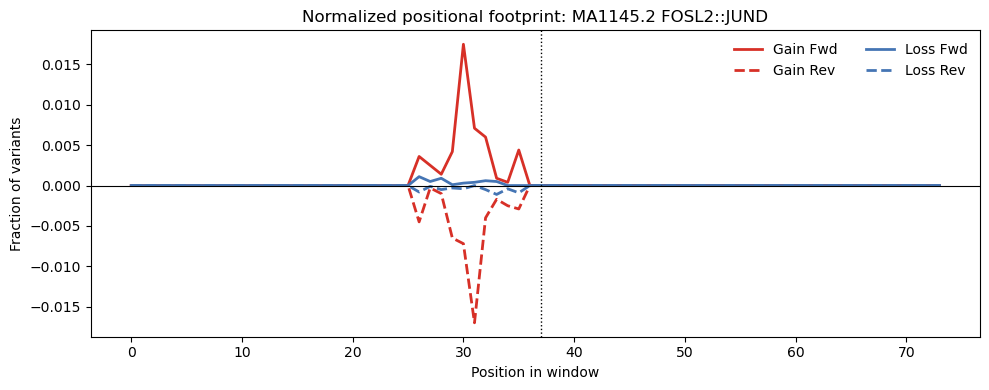

In [20]:
N = obj["Idx_Sequence"].shape[0]
plt.figure(figsize=(10, 4))
plt.plot(x, gain_fwd / N, color="#d73027", lw=2, label="Gain Fwd")
plt.plot(x, -(gain_rev / N), color="#d73027", lw=2, ls="--", label="Gain Rev")
plt.plot(x, loss_fwd / N, color="#4575b4", lw=2, label="Loss Fwd")
plt.plot(x, -(loss_rev / N), color="#4575b4", lw=2, ls="--", label="Loss Rev")
plt.axvline(P // 2, color="black", lw=1, ls=":")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Position in window")
plt.ylabel("Fraction of variants")
plt.title(f"Normalized positional footprint: {motif_name}")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

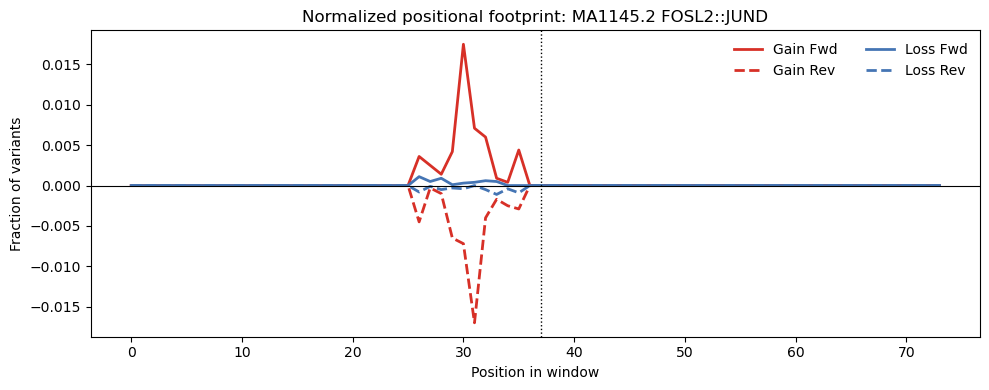

In [21]:
N = obj["Idx_Sequence"].shape[0]
plt.figure(figsize=(10, 4))
plt.plot(x, gain_fwd / N, color="#d73027", lw=2, label="Gain Fwd")
plt.plot(x, -(gain_rev / N), color="#d73027", lw=2, ls="--", label="Gain Rev")
plt.plot(x, loss_fwd / N, color="#4575b4", lw=2, label="Loss Fwd")
plt.plot(x, -(loss_rev / N), color="#4575b4", lw=2, ls="--", label="Loss Rev")
plt.axvline(P // 2, color="black", lw=1, ls=":")
plt.axhline(0, color="black", lw=0.8)
plt.xlabel("Position in window")
plt.ylabel("Fraction of variants")
plt.title(f"Normalized positional footprint: {motif_name}")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

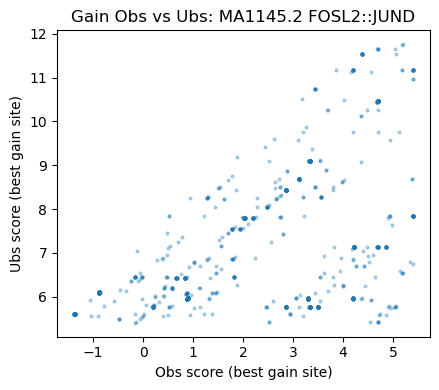

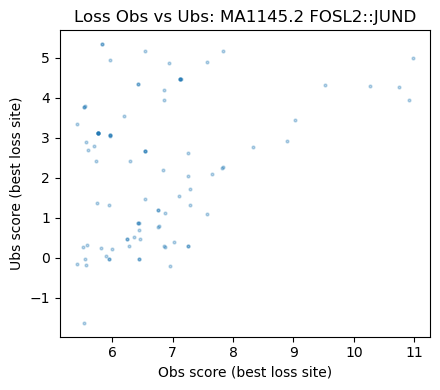

In [22]:
gain_any_nm = obj["Gain_Any"][:, m]
loss_any_nm = obj["Loss_Any"][:, m]

gain_obs = obj["Gain_Obs"][:, m]
gain_ubs = obj["Gain_Ubs"][:, m]
loss_obs = obj["Loss_Obs"][:, m]
loss_ubs = obj["Loss_Ubs"][:, m]

# Gain scatter (Obs vs Ubs)
plt.figure(figsize=(4.5, 4))
plt.scatter(gain_obs[gain_any_nm], gain_ubs[gain_any_nm], s=4, alpha=0.3)
plt.xlabel("Obs score (best gain site)")
plt.ylabel("Ubs score (best gain site)")
plt.title(f"Gain Obs vs Ubs: {motif_name}")
plt.tight_layout()
plt.show()

# Loss scatter
plt.figure(figsize=(4.5, 4))
plt.scatter(loss_obs[loss_any_nm], loss_ubs[loss_any_nm], s=4, alpha=0.3)
plt.xlabel("Obs score (best loss site)")
plt.ylabel("Ubs score (best loss site)")
plt.title(f"Loss Obs vs Ubs: {motif_name}")
plt.tight_layout()
plt.show()

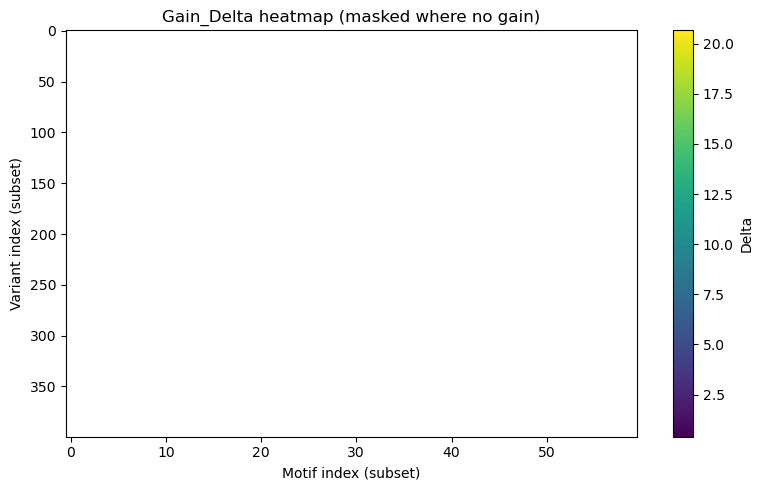

In [23]:
Gain_Any = obj["Gain_Any"]          # (N, M) bool
Gain_Delta = obj["Gain_Delta"]      # (N, M) float32

# take a manageable subset for plotting
n_show = 400
m_show = 60
mat = Gain_Delta[:n_show, :m_show]
mask = ~Gain_Any[:n_show, :m_show]

mat_masked = np.ma.array(mat, mask=mask)  # masked cells are transparent

plt.figure(figsize=(8, 5))
plt.imshow(mat_masked, aspect="auto")
plt.xlabel("Motif index (subset)")
plt.ylabel("Variant index (subset)")
plt.title("Gain_Delta heatmap (masked where no gain)")
plt.colorbar(label="Delta")
plt.tight_layout()
plt.show()

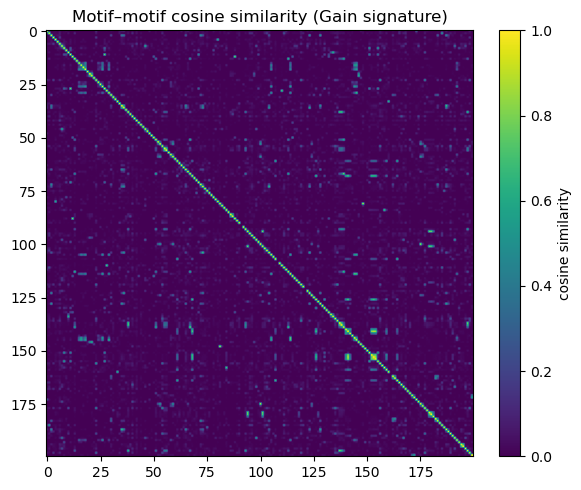

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# Use a subset of motifs to keep this fast for a first view
m_show = 200
X = obj["Gain_Delta"][:, :m_show].astype(np.float32)  # (N, m_show)

# Optionally mask zeros (no-event) by multiplying with Gain_Any
X = X * obj["Gain_Any"][:, :m_show]

sim = cosine_similarity(X.T)  # (m_show, m_show)

plt.figure(figsize=(6, 5))
plt.imshow(sim, aspect="auto")
plt.title("Motif–motif cosine similarity (Gain signature)")
plt.colorbar(label="cosine similarity")
plt.tight_layout()
plt.show()

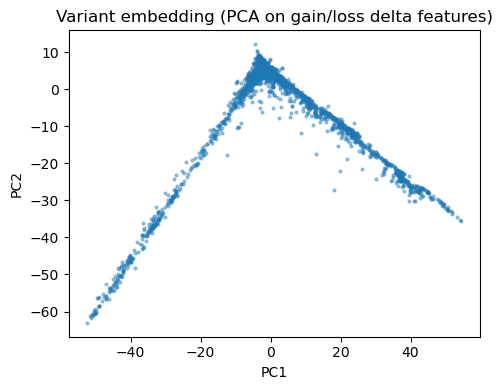

In [25]:
from sklearn.decomposition import PCA

# Build a feature matrix for variants: concatenate gain and loss deltas (simple, effective)
Xg = obj["Gain_Delta"].astype(np.float32) * obj["Gain_Any"]
Xl = obj["Loss_Delta"].astype(np.float32) * obj["Loss_Any"]
X = np.concatenate([Xg, Xl], axis=1)  # (N, 2M)

# PCA on a subset of variants for speed in notebook
n_sub = 5000
Xp = X[:n_sub]

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xp)

plt.figure(figsize=(5, 4))
plt.scatter(Z[:, 0], Z[:, 1], s=4, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Variant embedding (PCA on gain/loss delta features)")
plt.tight_layout()
plt.show()